<a href="https://colab.research.google.com/github/Jokiba/ml-predicted-category-product-final-project/blob/main/notebooks/product_category_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creating prediction models - product categories

## Steps in the process of creating a model

In this notebook we will do the following steps:



* Data distribution into training and test
* Preparing data for the model - ColumnTransformer preprocessing

* Dictionary creation with algorithms for multiple models

* Model training and testing

* Model performance evaluation

* Confusion matrix (heatmap) for each model



## Loading data
We are loading a cleaned and improved product dataset with a new 'category_in_title' column.<br> This column will help predict the product category.<br>Converting the columns to the appropriate type that the model will work with more easily.

In [1]:
import pandas as pd

# load dataset from GitHub
url = "https://raw.githubusercontent.com/Jokiba/ml-predicted-category-product-final-project/main/data/products_clean.csv"
df_clean = pd.read_csv(url)

# Converting columns to the appropriate type
df_clean[['category_label', 'category_in_title']] = df_clean[['category_label', 'category_in_title']].astype('category')

# Check dataset
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35096 entries, 0 to 35095
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   product_title      35096 non-null  object  
 1   category_label     35096 non-null  category
 2   category_in_title  21641 non-null  category
dtypes: category(2), object(1)
memory usage: 343.6+ KB


## Data distribution
In this step, we divide the data into a training and a test set.<br>The distribution of categories remains the same in both sets.<br>In both sets there are columns from which the model learns and the target variable as a result that the model guesses.

In [2]:
# Importing the required module
from sklearn.model_selection import train_test_split

# Features and label
X = df_clean[["product_title", "category_in_title"]]
y = df_clean["category_label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=777, stratify=y
)

## Defining input data
We select the columns for the input data.<br>By placing the columns in the variable object, we define the type of text and category columns.

In [3]:
# Defining columns
text_feature = "product_title"
categorical_feature = ["category_in_title"]



## Preparing data for the model
We create a ColumnTransformer that allows vectorization of a text column and encoding of a categorical column.

In [4]:
# Importing the required modules
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

# ColumnTransformer (TF-IDF + OneHot)
preprocessor = ColumnTransformer(
    transformers=[
        # TF-IDF for product name
        ("title_tfidf", TfidfVectorizer(
            ngram_range=(1, 2),
            max_df=0.9,
            min_df=5,
            stop_words="english"
        ), text_feature),

        # One-Hot for category_in_title
        ("category_ohe", OneHotEncoder(
            handle_unknown="ignore"
        ), categorical_feature)
    ]
)

## Placing algorithms in a dictionary
We import the Pipeline, which allows us a cleaner code.<br>We also used it to combine several steps into one whole.<br>We import the desired algorithms, which help us to create models<br>We place the algorithms in a dictionary that we will later call to create models.

In [5]:
# Importing the required modules
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Algorithms placed inside a dictionary
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    ),
    "Multinomial NB": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(
        random_state=777
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=777,
        n_jobs=-1
    ),
    "Linear SVC": LinearSVC()
}

## Training, prediction and evaluation of models
In this step, we use a counting loop to go through the dictionary of algorithms.<br>Pipeline combines data transformation, training, prediction and finally evaluation of the model into one unit.<br>We print metrics for each model.<br>We visually display the confusion matrix.<br>In this way, we compare the performance of the models and select the best one.<br>We do all this inside the loop for each model separately.

MODEL: Logistic Regression
                 precision    recall  f1-score   support

         camera       0.99      0.99      0.99       538
            cpu       1.00      0.99      1.00       766
     dishwasher       0.92      0.95      0.94       681
        freezer       0.96      0.89      0.92       440
         fridge       0.92      0.89      0.91       712
 fridge freezer       0.92      0.92      0.92      1094
      microwave       0.98      0.95      0.97       466
          phone       0.96      0.99      0.98       812
             tv       0.97      0.99      0.98       708
washing machine       0.94      0.96      0.95       803

       accuracy                           0.95      7020
      macro avg       0.96      0.95      0.95      7020
   weighted avg       0.95      0.95      0.95      7020



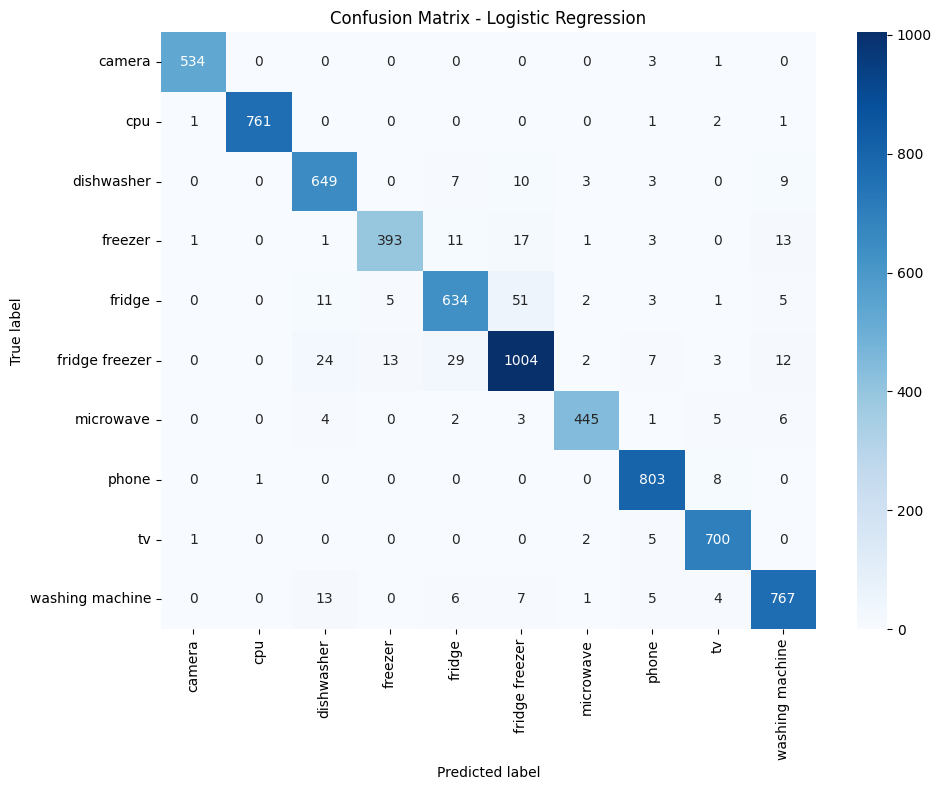

MODEL: Multinomial NB
                 precision    recall  f1-score   support

         camera       0.99      0.99      0.99       538
            cpu       0.98      1.00      0.99       766
     dishwasher       0.91      0.97      0.94       681
        freezer       0.97      0.87      0.92       440
         fridge       0.84      0.91      0.87       712
 fridge freezer       0.94      0.89      0.91      1094
      microwave       0.99      0.95      0.97       466
          phone       0.97      0.99      0.98       812
             tv       0.99      0.97      0.98       708
washing machine       0.95      0.96      0.95       803

       accuracy                           0.95      7020
      macro avg       0.95      0.95      0.95      7020
   weighted avg       0.95      0.95      0.95      7020



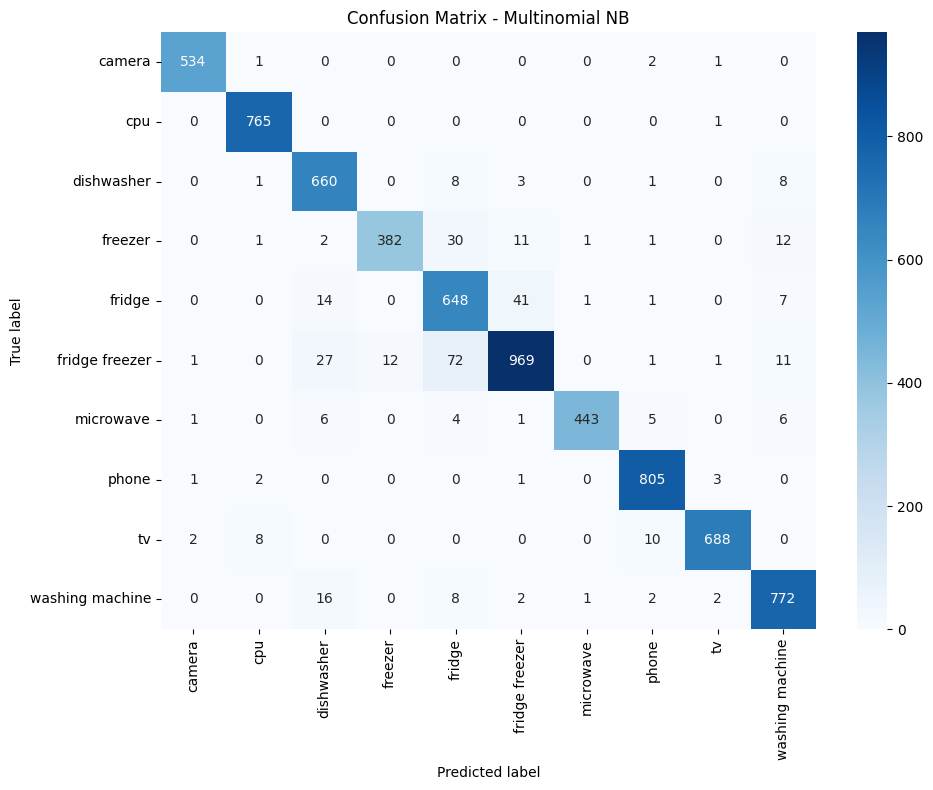

MODEL: Decision Tree
                 precision    recall  f1-score   support

         camera       0.99      0.98      0.99       538
            cpu       0.96      1.00      0.98       766
     dishwasher       0.91      0.95      0.93       681
        freezer       0.91      0.89      0.90       440
         fridge       0.91      0.86      0.88       712
 fridge freezer       0.92      0.91      0.91      1094
      microwave       0.96      0.94      0.95       466
          phone       0.98      0.97      0.98       812
             tv       0.96      0.98      0.97       708
washing machine       0.93      0.95      0.94       803

       accuracy                           0.94      7020
      macro avg       0.94      0.94      0.94      7020
   weighted avg       0.94      0.94      0.94      7020



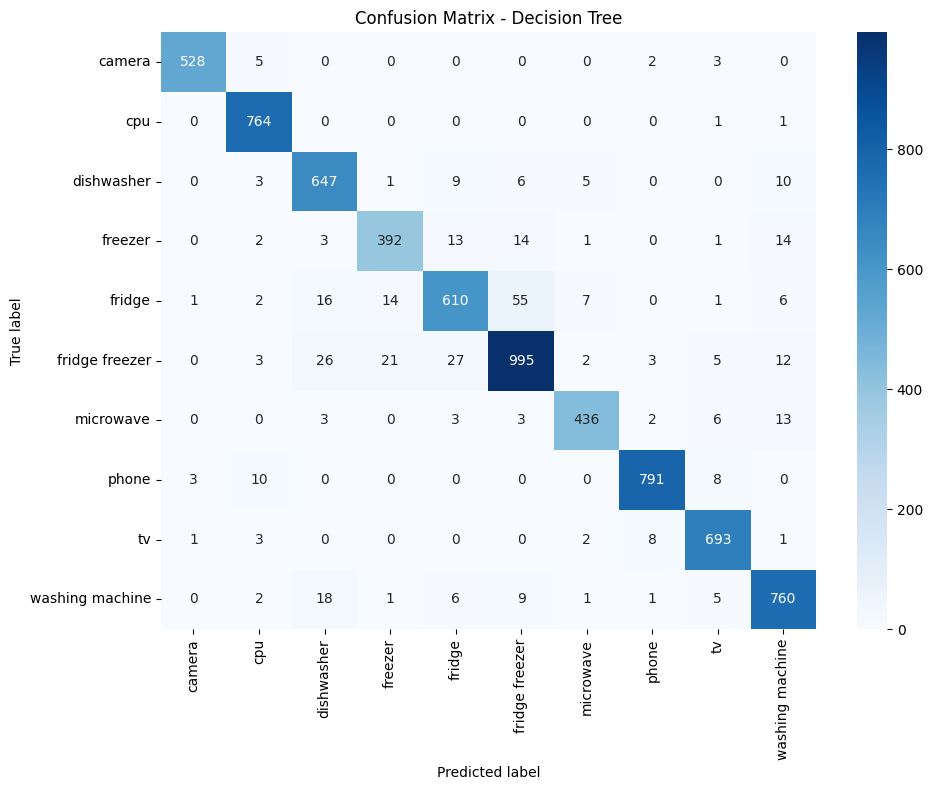

MODEL: Random Forest
                 precision    recall  f1-score   support

         camera       0.99      0.99      0.99       538
            cpu       1.00      0.99      1.00       766
     dishwasher       0.92      0.96      0.94       681
        freezer       0.93      0.90      0.91       440
         fridge       0.91      0.89      0.90       712
 fridge freezer       0.93      0.92      0.92      1094
      microwave       0.97      0.95      0.96       466
          phone       0.98      0.98      0.98       812
             tv       0.96      0.99      0.97       708
washing machine       0.94      0.95      0.95       803

       accuracy                           0.95      7020
      macro avg       0.95      0.95      0.95      7020
   weighted avg       0.95      0.95      0.95      7020



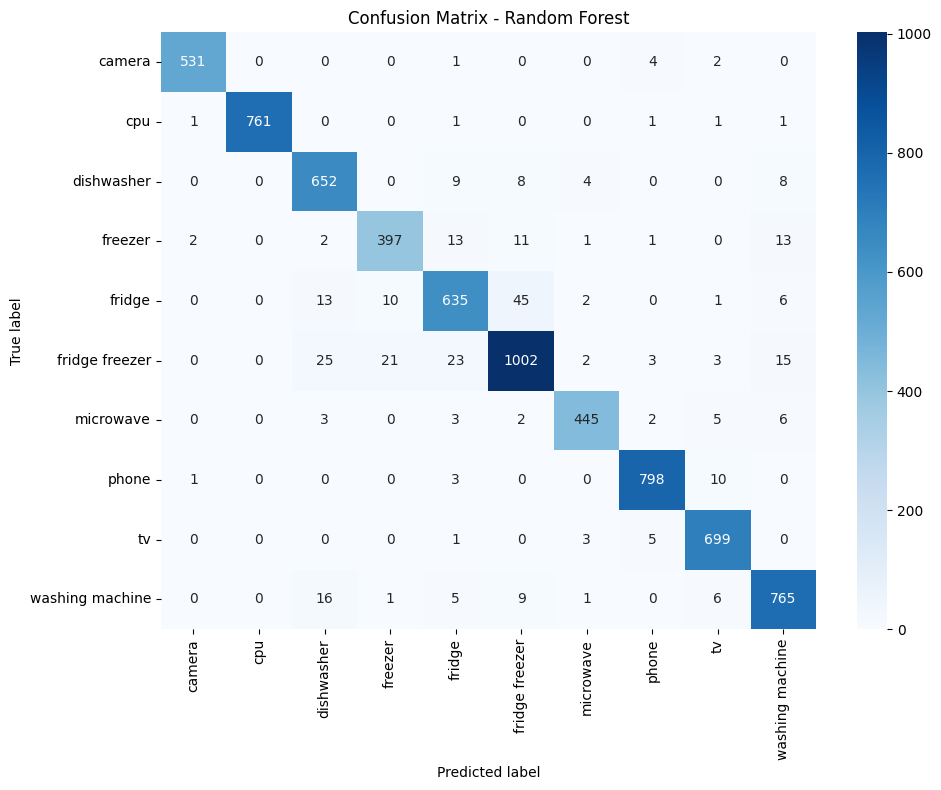

MODEL: Linear SVC
                 precision    recall  f1-score   support

         camera       0.99      0.99      0.99       538
            cpu       1.00      0.99      1.00       766
     dishwasher       0.92      0.96      0.94       681
        freezer       0.93      0.91      0.92       440
         fridge       0.92      0.89      0.91       712
 fridge freezer       0.93      0.92      0.93      1094
      microwave       0.97      0.96      0.97       466
          phone       0.99      0.99      0.99       812
             tv       0.96      0.99      0.98       708
washing machine       0.94      0.96      0.95       803

       accuracy                           0.96      7020
      macro avg       0.96      0.96      0.96      7020
   weighted avg       0.96      0.96      0.96      7020



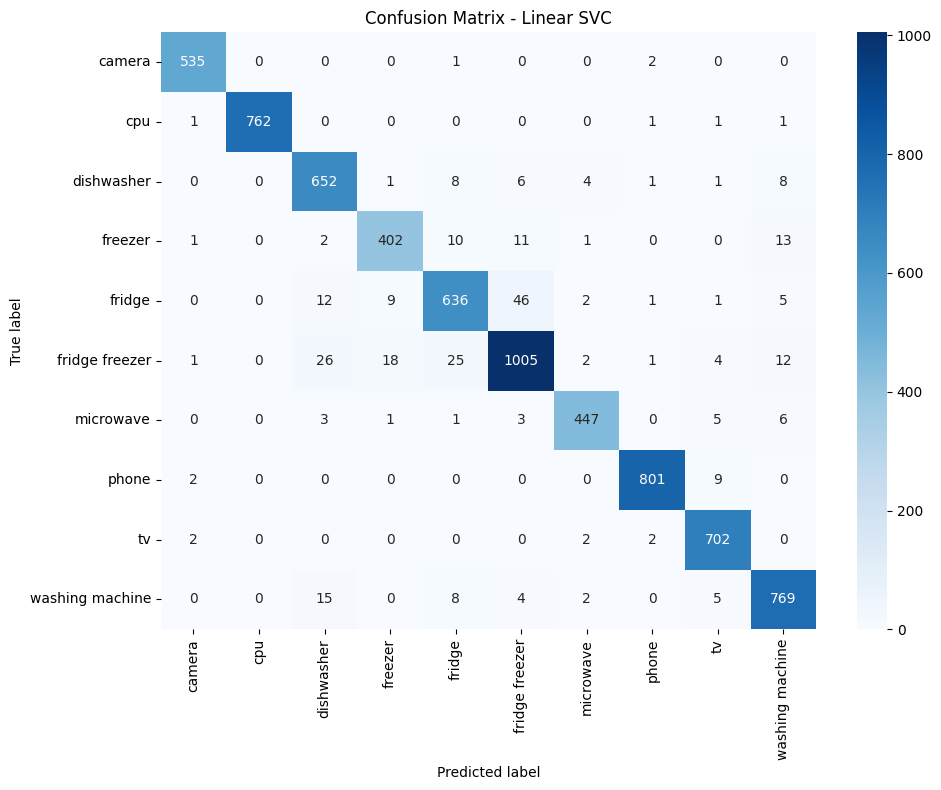

In [6]:
# Importing the required module
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Counter loop with Pipeline and the whole process
for name, clf in models.items():
    print("=" * 60)
    print(f"MODEL: {name}")

    pipeline = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("classifier", clf)
        ]
    )

    # Model training
    pipeline.fit(X_train, y_train)

    # Model prediction
    y_pred = pipeline.predict(X_test)

    # Model evaluation
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Confusion matrix visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=pipeline.classes_,
        yticklabels=pipeline.classes_
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


## Report Analysis for choosing best one
After reviewing the performance of the models, we can say that all of them have high accuracy, precision, response and f1 balance mostly above 90%.<br>The models achieved the weakest prediction for three product categories: freezer, fridge and fridge freezer.<br>Most likely due to their similarity, here in some models the parameters fall below 90%, but it is still a good percentage.<br>The Linear SVC model is slightly ahead of the others when we look at the overall picture of the analysis.